In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    confusion_matrix,
    classification_report, 
    roc_auc_score,
    roc_curve
)

In [31]:
df = pd.read_csv('hotel_bookings_cleaned.csv')

In [32]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_guests,total_nights,is_family,booking_status
0,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,...,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
1,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,...,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
2,Resort Hotel,0,7,2015,July,27,1,0,1.0,1,...,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
3,Resort Hotel,0,13,2015,July,27,1,0,1.0,1,...,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
4,Resort Hotel,0,14,2015,July,27,1,0,2.0,2,...,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2,2.0,0,Not Cancelled


In [33]:
df.shape

(87203, 36)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87203 entries, 0 to 87202
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87203 non-null  object 
 1   is_canceled                     87203 non-null  int64  
 2   lead_time                       87203 non-null  int64  
 3   arrival_date_year               87203 non-null  int64  
 4   arrival_date_month              87203 non-null  object 
 5   arrival_date_week_number        87203 non-null  int64  
 6   arrival_date_day_of_month       87203 non-null  int64  
 7   stays_in_weekend_nights         87203 non-null  int64  
 8   stays_in_week_nights            87203 non-null  float64
 9   adults                          87203 non-null  int64  
 10  children                        87203 non-null  int64  
 11  babies                          87203 non-null  int64  
 12  meal                            

In [35]:
features = [
    "lead_time",
    "adr",
    "total_guests",
    "total_nights",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "days_in_waiting_list",
    "is_repeated_guest"
]

X = df[features]
y = df["is_canceled"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [38]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

print(f"Precision: {precision_score(y_test, y_pred)}")

print(f"Recall: {recall_score(y_test, y_pred)}")

print(f"F1 Score: {f1_score(y_test, y_pred)}")

Accuracy: 0.7618829195573649
Precision: 0.588395532552438
Recall: 0.4498125780924615
F1 Score: 0.5098548329989379


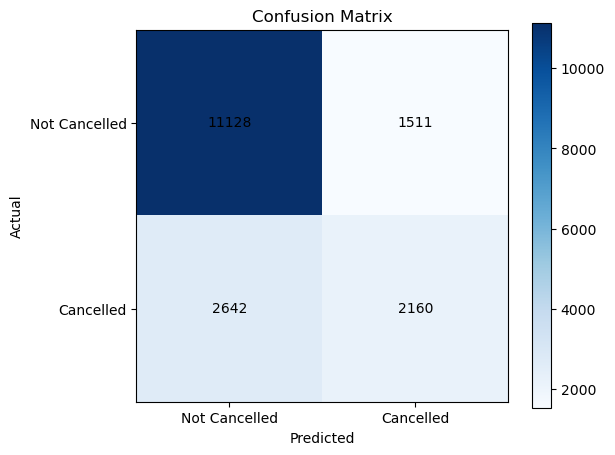

In [39]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks([0,1],["Not Cancelled", "Cancelled"])
plt.yticks([0,1],["Not Cancelled", "Cancelled"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                ha="center",
                va="center"
)

plt.show()

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84     12639
           1       0.59      0.45      0.51      4802

    accuracy                           0.76     17441
   macro avg       0.70      0.67      0.68     17441
weighted avg       0.75      0.76      0.75     17441



In [41]:
scores = cross_val_score(
    rf, 
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")

print(scores)

print("Average Accuracy")

print(scores.mean())

Cross Validation Scores
[0.73590964 0.70420274 0.66911301 0.66565367 0.67207569]
Average Accuracy
0.6893909492501324


In [42]:
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [44]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [45]:
print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
0.7773573035492022


In [46]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [47]:
print(classification_report(y_test,y_pred))

print("Accuracy")

print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     12639
           1       0.68      0.39      0.49      4802

    accuracy                           0.78     17441
   macro avg       0.74      0.66      0.68     17441
weighted avg       0.77      0.78      0.76     17441

Accuracy
0.7798864743994037


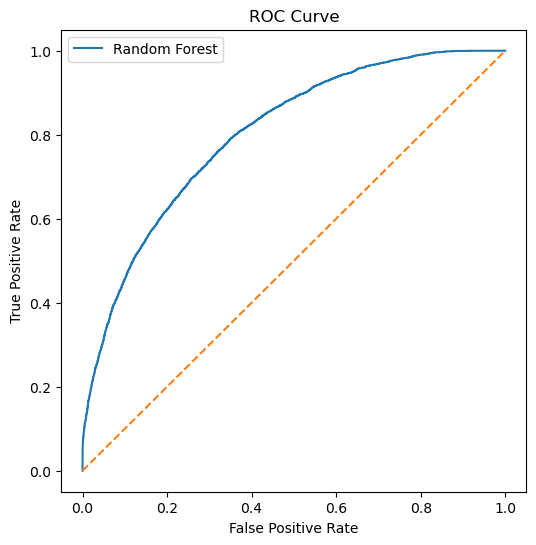

In [48]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [49]:
print("ROC AUC")

print(roc_auc_score(y_test,y_prob))

ROC AUC
0.8021100489586204


In [50]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                           Feature  Importance
0                        lead_time    0.294277
1                              adr    0.265636
3                     total_nights    0.086785
7        total_of_special_requests    0.085780
8      required_car_parking_spaces    0.080433
6                  booking_changes    0.056385
4           previous_cancellations    0.054863
2                     total_guests    0.044499
5   previous_bookings_not_canceled    0.016903
9             days_in_waiting_list    0.007677
10               is_repeated_guest    0.006764


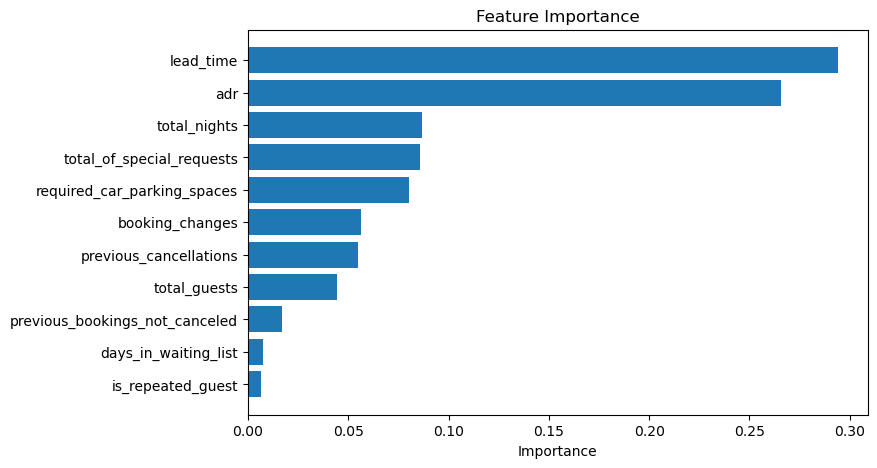

In [51]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()